# Autograd Engine from Scratch 
(Combination of Karpathy's Micrograd and Pytorch)

A minimal autograd engine and neural network library built from scratch in Python.

This project implements:
- Reverse-mode automatic differentiation
- A multi-layer perceptron (MLP)
- Gradient-based optimization (SGD + Adam)
- Training on synthetic datasets with visualization

In [10]:
import math, random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Autograd Engine (Value class)

Implements a scalar value that tracks operations and supports automatic differentiation via backpropagation.

In [11]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
        
    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __rmul__(self, other):
        return self * other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
            

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



## 2. Neural Network Components
- Neurons
- Layers
- Multi-layer perceptron (MLP)

In [13]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out
    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


 

## 3. Optimization Algorithms

We implement gradient descent and Adam optimizer for training.

In [31]:
class SGD:
    def __init__(self, params, lr=0.01):
        self.params = params
        self.lr = lr

    def step(self):
        for p in self.params:
            p.data -= self.lr * p.grad

    def zero_grad(self):
        for p in self.params:
            p.grad = 0.0
            

class Adam:
    def __init__(self, params, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        
        self.m = [0 for _ in params]  # first moment
        self.v = [0 for _ in params]  # second moment
        self.t = 0

    def zero_grad(self):
        for p in self.params:
            p.grad = 0.0

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            g = p.grad

            # update moments
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)

            # bias correction
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # update
            p.data -= self.lr * m_hat / (v_hat ** 0.5 + self.eps)

## 4. Experiment 1: Toy Dataset (Sanity Check)

Before training on real data, first test the neural network on a small handcrafted dataset.
Verify that:
- The model can learn simple nonlinear relationships
- Backpropagation and optimization are working correctly
- Loss decreases over time
  
This serves as a sanity check for the implementation of our autograd engine and MLP.

0 4.00826570851026
1 3.563541328965357
2 3.155997854883646
3 2.7956199824403996
4 2.4846822746659996
5 2.217486972792726
6 1.9844009164616276
7 1.7760509836286875
8 1.5854431218816663
9 1.408330841337429
10 1.2428198291420238
11 1.0886566090548635
12 0.9464568590115756
13 0.8170561060289917
14 0.7010702190610285
15 0.5986719087414611
16 0.5095409945612973
17 0.4329276214215875
18 0.3677706018065626
19 0.3128278941029811
20 0.2667934466939377
21 0.22838838632260022
22 0.1964235002575312
23 0.16983525350108283
24 0.14770040951359845
25 0.12923535243959364
26 0.11378590209822859
27 0.10081230089521637
28 0.08987267052096554
29 0.08060697167370798
30 0.07272253293011062
31 0.06598156834585112
32 0.06019072014809454
33 0.05519246467029887
34 0.050858137483033986
35 0.047082317235064286
36 0.04377832448823678
37 0.04087462252382027
38 0.03831194119948601
39 0.036040977251879054
40 0.03402055279574187
41 0.03221613759170522
42 0.030598660141370936
43 0.029143548343132077
44 0.0278299529164107

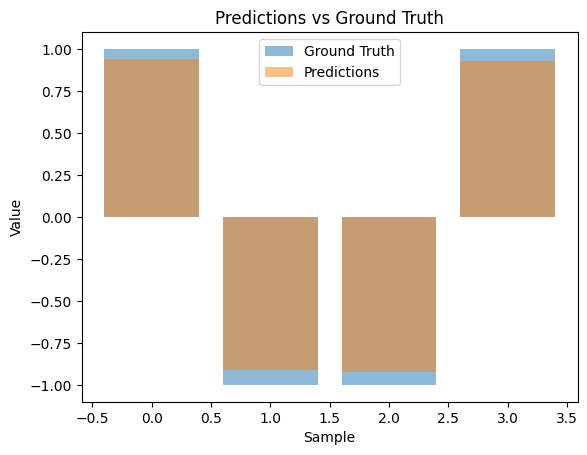

In [40]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

n = MLP(3, [4, 4, 1])
opt = Adam(n.parameters(), lr=0.01)

losses = []

for k in range(50):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    opt.zero_grad()
    loss.backward()
    opt.step()

    losses.append(loss.data)
    print(k, loss.data)

pred_vals = [y.data for y in ypred]

x_axis = range(len(ys))

plt.bar(x_axis, ys, alpha=0.5, label="Ground Truth")
plt.bar(x_axis, pred_vals, alpha=0.5, label="Predictions")



plt.legend()
plt.title("Predictions vs Ground Truth")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.show()


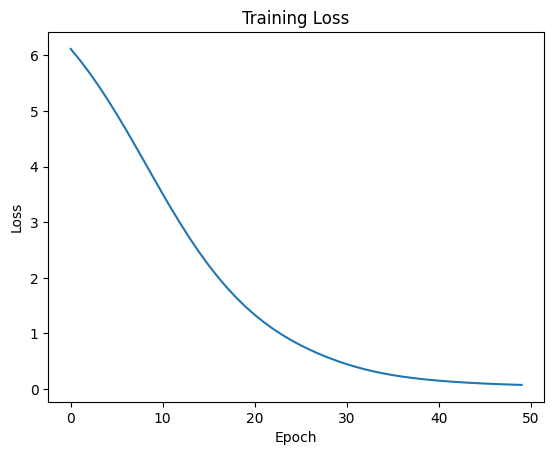

In [39]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
ypred = [n(x) for x in xs]



## 5. Experiment 2: Non-Linear Classification (Moons Dataset)

We now evaluate the model on a more realistic dataset: the "two moons" dataset.

Unlike the toy dataset, this problem is:
- Not linearly separable
- Requires non-linear decision boundaries
- A better test of the neural network's expressive power

Verify that the MLP can:
- Learn complex non-linear patterns
- Generalize beyond simple handcrafted data
- Form meaningful decision boundaries using hidden layers

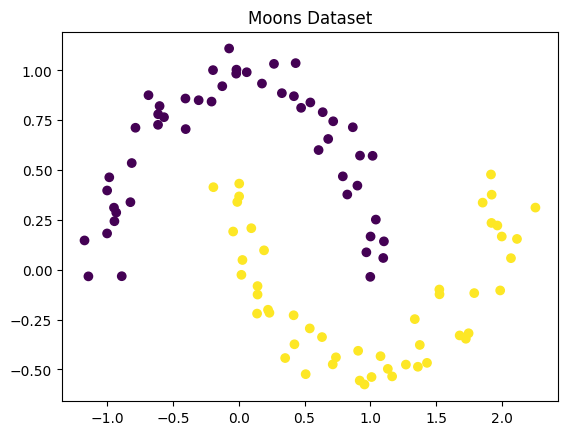

0 196.29158051210845
1 183.08440805879744
2 161.0596859822574
3 142.69504723896094
4 127.07244188470483
5 111.93443660076605
6 99.11238263711682
7 88.83506922620668
8 80.44056725386018
9 73.3736801048815
10 67.38344560174967
11 62.249428480596166
12 57.779290607488
13 53.850273716880764
14 50.39616959053059
15 47.38819761148048
16 44.81853179137113
17 42.70777207906015
18 41.12507974681764
19 40.13884831461541
20 39.69238347516441
21 39.56281288969422
22 39.47326867661589
23 39.23724003940584
24 38.83882279041625
25 38.4240569251359
26 38.152430467587855
27 37.98131858058541
28 37.6551191291637
29 36.96089862981034
30 35.92538075518645
31 34.75803116903205
32 33.67135528460474
33 32.766941925966556
34 32.04011270259265
35 31.429344629278937
36 30.85341101082035
37 30.236876436370608
38 29.525812670231943
39 28.6915143395713
40 27.72714179481264
41 26.64315756280838
42 25.463421962680254
43 24.22089771211564
44 22.95154725485388
45 21.68683787555511
46 20.44796839590636
47 19.2457265500

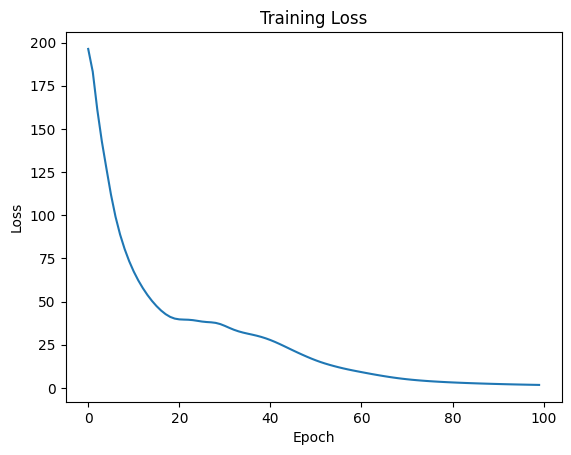

In [35]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.1)

xs = X.tolist()
ys = [1.0 if label == 1 else -1.0 for label in y]

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Moons Dataset")
plt.show()

n = MLP(2, [16, 16, 1])
opt = Adam(n.parameters(), lr=0.01)

losses = []

for k in range(100):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    opt.zero_grad()
    loss.backward()
    opt.step()

    losses.append(loss.data)
    print(k, loss.data)

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()



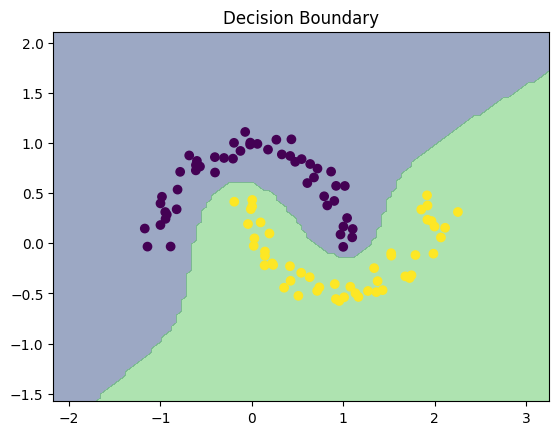

In [36]:
import numpy as np

# grid
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# predict on grid
Z = []
for i in range(len(xx)):
    row = []
    for j in range(len(xx[0])):
        pred = n([xx[i][j], yy[i][j]])
        row.append(pred.data)
    Z.append(row)

Z = np.array(Z)

# plot
plt.contourf(xx, yy, Z > 0, alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Decision Boundary")
plt.show()

## 8. Results & Conclusion

### Results
- The model successfully learns both the toy dataset and the non-linear moons dataset.
- Training loss decreases consistently, showing correct backpropagation and optimization.
- The decision boundary shows that the network can separate non-linear classes.

### Conclusion
This project implements a simple neural network from scratch with automatic differentiation, backpropagation, and gradient-based optimization. It demonstrates how deep learning models learn patterns from data.